# End-to-End Demo

Tutorial notebooks (`01`-`07`) build every component from scratch in-place. This notebook is the *showcase*: it imports the finished package from `src/transformer/` and runs the full pipeline end-to-end.

1. Load the Shakespeare corpus and build a char vocabulary
2. Instantiate the decoder-only transformer
3. Sample text from the untrained model (random baseline)
4. Train for 3000 steps with Adam
5. Plot the loss curve
6. Sample text at different temperatures
7. Visualize a learned attention head

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from transformer.data import load_corpus
from transformer.generate import generate
from transformer.model import Transformer
from transformer.train import TrainConfig, train

np.random.seed(42)
rng = np.random.default_rng(42)

## 1. Corpus and vocabulary

In [2]:
text, vocab, data = load_corpus('../data/input.txt')

print(f'Corpus length: {len(text):,} chars')
print(f'Vocab size:    {vocab.size}')
print(f'Characters:    {repr("".join(vocab.chars))}')

Corpus length: 10,160 chars
Vocab size:    58
Characters:    "\n !',-.:;?ABCDEFGHIJLMNOPRSTUVWYabcdefghijklmnopqrstuvwxyz"


## 2. Model

In [3]:
model = Transformer(
    vocab_size=vocab.size,
    d_model=64,
    n_heads=4,
    d_ff=256,
    n_layers=3,
    max_seq_len=32,
)
print(f'Parameters: {model.count_params():,}')

Parameters: 156,794


## 3. Sample before training

In [4]:
print(generate(model, vocab, start='First', max_new_tokens=120, temperature=1.0, rng=rng))

FirstpSriAyoqBUSuirVFbArfoOysqFW.DgkyLOVFCVFgSriJrqOIgDF
qgiqUbDAgVbnfbbI,SFPrF;IIfbqgPrD'AiUDWDiSOIfOAAxtiHyoiSHAtUFJbErniSf


## 4. Train

In [5]:
config = TrainConfig(n_steps=3000, batch_size=32, seq_len=32, lr=1e-3, log_every=500)
losses = train(model, data, config, rng=rng)

step   500/3000 | loss 2.6114 | 57.5 steps/s


step  1000/3000 | loss 1.8555 | 59.5 steps/s


step  1500/3000 | loss 1.4410 | 58.5 steps/s


step  2000/3000 | loss 1.0758 | 57.6 steps/s


step  2500/3000 | loss 0.7748 | 58.5 steps/s


step  3000/3000 | loss 0.5788 | 58.5 steps/s


## 5. Loss curve

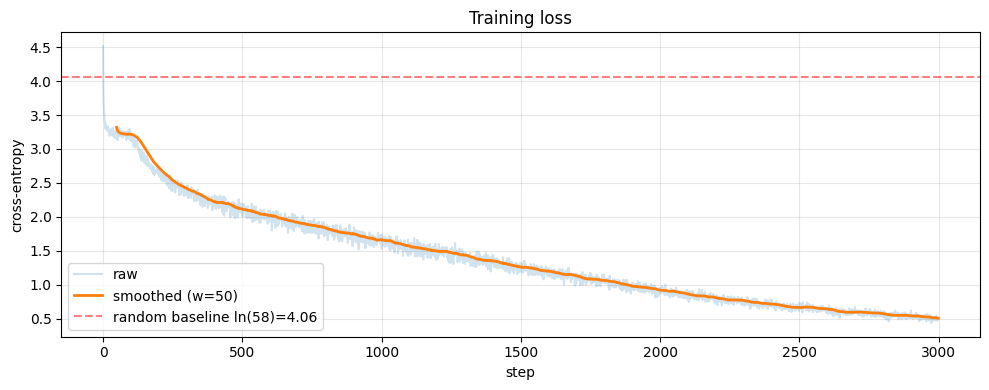

In [6]:
window = 50
smoothed = np.convolve(losses, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.2, label='raw')
plt.plot(range(window - 1, len(losses)), smoothed, linewidth=2, label=f'smoothed (w={window})')
plt.axhline(np.log(vocab.size), color='red', linestyle='--', alpha=0.5, label=f'random baseline ln({vocab.size})={np.log(vocab.size):.2f}')
plt.xlabel('step')
plt.ylabel('cross-entropy')
plt.title('Training loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Sample after training

In [7]:
for temp in (0.3, 0.8, 1.2):
    print(f'--- temperature = {temp} ---')
    print(generate(model, vocab, start='First Citizen', max_new_tokens=200, temperature=temp, rng=rng))
    print()

--- temperature = 0.3 ---


First Citizen:
We helpom they with done famously beat us p,
And you the but efery to their ruth,
And let me mutinous members; for examine
Their ome with belly be roike Ve upower and thous stand not in their ruthei

--- temperature = 0.8 ---


First Citizen:
We hich on naturaltte; the other instrument in your in sto you the with belly?
T Baind poortency
Whilel flatts didlet with being states do the cre?

MARCIUS:
He these?

First Citizen:
Soft! who the 

--- temperature = 1.2 ---


First Citizen:
First, you know I

That enver bearing
Appoment; whereous,
Sis your stiff thours defenc eregemembers, they shough soft-cond greatness ;enates they rest were se!

MARCIUS:
They make it we be:od's you,



## 7. Learned attention head

Feed a short prompt through the trained model and inspect the attention weights from head 0 of block 0.

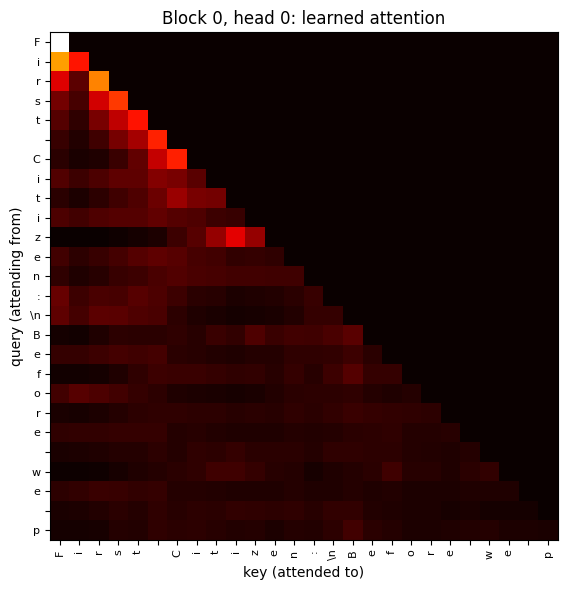

In [8]:
sample = 'First Citizen:\nBefore we p'
indices = np.array([vocab.encode(sample)])
_ = model.forward(indices)

attn = model.blocks[0].mha.attn_weights[0, 0]
tokens = [c if c != '\n' else '\\n' for c in sample]
T = len(tokens)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(attn[:T, :T], cmap='hot', vmin=0)
ax.set_xticks(range(T))
ax.set_xticklabels(tokens, fontsize=8, rotation=90)
ax.set_yticks(range(T))
ax.set_yticklabels(tokens, fontsize=8)
ax.set_xlabel('key (attended to)')
ax.set_ylabel('query (attending from)')
ax.set_title('Block 0, head 0: learned attention')
plt.tight_layout()
plt.show()